In [9]:
import pandas as pd
import seaborn as sns
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error


In [3]:
insurance_data = pd.read_csv('insurance.csv')

In [4]:
X = insurance_data .drop(columns = ['charges'])
y = insurance_data['charges']
X=pd.get_dummies(X , columns=['region'],drop_first = True , dtype=int)
X

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest
0,19,female,27.900,0,yes,0,0,1
1,18,male,33.770,1,no,0,1,0
2,28,male,33.000,3,no,0,1,0
3,33,male,22.705,0,no,1,0,0
4,32,male,28.880,0,no,1,0,0
...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,1,0,0
1334,18,female,31.920,0,no,0,0,0
1335,18,female,36.850,0,no,0,1,0
1336,21,female,25.800,0,no,0,0,1


In [5]:
X["sex"] = X["sex"].map({
    "female": 1,
    "male": 0
})

X["smoker"] = X["smoker"].map({
    "yes": 1,
    "no": 0
})
X


,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,0,0,1
1,18,0,33.770,1,0,0,1,0
2,28,0,33.000,3,0,0,1,0
3,33,0,22.705,0,0,1,0,0
4,32,0,28.880,0,0,1,0,0
...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,1,0,0
1334,18,1,31.920,0,0,0,0,0
1335,18,1,36.850,0,0,0,1,0
1336,21,1,25.800,0,0,0,0,1


In [6]:
# interactive features
X['age_smoker'] = X['age']*X['smoker']
X['bmi_score'] = X['bmi']*X['smoker']
X

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest,age_smoker,bmi_score
0,19,1,27.900,0,1,0,0,1,19,27.90
1,18,0,33.770,1,0,0,1,0,0,0.00
2,28,0,33.000,3,0,0,1,0,0,0.00
3,33,0,22.705,0,0,1,0,0,0,0.00
4,32,0,28.880,0,0,1,0,0,0,0.00
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,1,0,0,0,0.00
1334,18,1,31.920,0,0,0,0,0,0,0.00
1335,18,1,36.850,0,0,0,1,0,0,0.00
1336,21,1,25.800,0,0,0,0,1,0,0.00


In [7]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size = 0.2 , random_state=42)
X_train

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest,age_smoker,bmi_score
560,46,1,19.950,2,0,1,0,0,0,0.0
1285,47,1,24.320,0,0,0,0,0,0,0.0
1142,52,1,24.860,0,0,0,1,0,0,0.0
969,39,1,34.320,5,0,0,1,0,0,0.0
486,54,1,21.470,3,0,1,0,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...
1095,18,1,31.350,4,0,0,0,0,0,0.0
1130,39,1,23.870,5,0,0,1,0,0,0.0
1294,58,0,25.175,0,0,0,0,0,0,0.0
860,37,1,47.600,2,1,0,0,1,37,47.6


In [12]:
lasso_model = Lasso(alpha = 0.5)
lasso_model.fit(X_train,y_train)
y_pred = lasso_model.predict(X_test)
mse = mean_squared_error(y_pred , y_test)
print(mse)
mse = mean_squared_error(y_test , y_pred)
print(mse)

20918648.889825616
20918648.889825616


[20922446.697066024, 20918648.889825616, 20916337.804253954, 20914832.635089148, 20890881.000633504, 20878416.54387192, 20869462.906981695, 20868495.29410471, 20877828.532378826, 20907086.952911414, 20987912.106543407]


<Axes: >

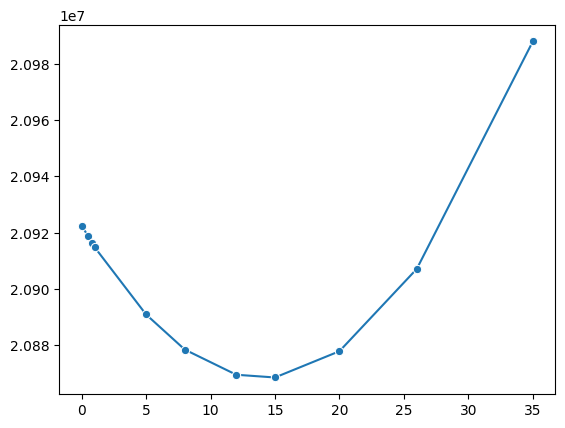

In [20]:
# if we dont we what values of alpha then simple what we can do is layman understanding run a for loop
alpha = [0.02 , 0.5,0.8,1,5,8,12,15,20,26,35]
mse = []
for a in alpha:
    lasso_model=Lasso(alpha=a)
    lasso_model.fit(X_train,y_train)
    y_pred = lasso_model.predict(X_test)
    mse1 = mean_squared_error(y_pred,y_test)
    mse.append(mse1)
print(mse)
sns.lineplot(x=alpha,y=mse,marker='o')

In [25]:
from sklearn.metrics import r2_score
from sklearn.linear_model import LassoCV
alpha = [0.02 , 0.5,0.8,1,5,8,12,15,20,26,35]

lasso_cv = LassoCV(
    alphas = alpha,
    cv=5,
    max_iter=1000,
    random_state=42
)

lasso_cv.fit(X_train,y_train)
print("Best Alpha value",lasso_cv.alpha_)
y_pred = lasso_cv.predict(X_test)
mse = mean_squared_error(y_pred,y_test)
r2 = r2_score(y_pred,y_test)
print(mse)
print(r2)

Best Alpha value 0.02
20922446.697066024
0.8508497307307221


In [27]:
from sklearn.metrics import r2_score, mean_squared_error 
from sklearn.linear_model import RidgeCV

alpha = [0.02, 0.5, 0.8, 1, 5, 8, 12, 15, 20, 26, 35]

ridge_cv = RidgeCV(
    alphas=alpha,
    cv=5
    # Removed: max_iter and random_state (not supported by RidgeCV)
)

ridge_cv.fit(X_train, y_train)
print("Best Alpha value:", ridge_cv.alpha_)

y_pred = ridge_cv.predict(X_test)
mse = mean_squared_error(y_test, y_pred)  
r2 = r2_score(y_test, y_pred)              

print("MSE:", mse)
print("R2 Score:", r2)


Best Alpha value: 0.02
MSE: 20918841.631424434
R2 Score: 0.8652559577755203
